# Analyse Experiment Results #

In [44]:
import os
import ast
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

## Analyse Dataset Selection Experiments with Negative Sampling & Smoothing Factor using Cold Start Setting ##

In [45]:
## util methods ##

def parse_cell(x):
    """
    Convert a cell into a Python object.
    Handles cases where the cell is already a list
    or stored as a string representation of a list.
    """
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return None
    if isinstance(x, str):
        x = x.strip()
        try:
            return ast.literal_eval(x)
        except Exception:
            try:
                return json.loads(x)
            except Exception:
                return None
    return x


def avg_fold_metrics(fold_value):
    """
    fold_value should be a list of 10 sublists, each sublist like:
    [auc, aupr, precision, sensitivity, specificity]

    Returns:
    [avg_auc, avg_aupr, avg_precision, avg_sensitivity, avg_specificity]
    """
    fold_value = parse_cell(fold_value)

    if not fold_value:
        return [np.nan] * 5

    arr = np.array(fold_value, dtype=float)   # shape should be (10, 5)
    return [round(x, 5) for x in arr.mean(axis=0).tolist()]

In [27]:
HYPERPARAM_SEARCH_PATH = "/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/hyperparam_search_2503.csv"
PREPROCESSED_HYPERPARAM_SEARCH_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/hyperparam_search_2503_preprocessed_.csv'

In [46]:
ABLATION_STRUDY_PATH = "/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/ablation_wo_struct_1504.csv"
PREPROCESSED_ABLATION_STRUDY_PATH = "/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/ablation_wo_struct_1304_preprocessed_.csv"

In [47]:
EXP_0303_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0103_full_.csv'
EXP_0803_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0803.csv'
EXP_0903_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0903.csv'
EXP_1003_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_1003.csv'
EXP_1203_VPATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_1203.csv' # VICTOR
EXP_1503_VPATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_eval_neg_smoo_1503.csv' # VICTOR
EXP_1703_VPATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_eval_neg_smoo_1703.csv' # VICTOR
EXP_2003_VPATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_both_eval_2003.csv' # VICTOR

# preprocessed csv files name - for saving preprocessed results 
PREPROCESSED_EXP_0303_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0103_full_preprocessed_.csv'
PREPROCESSED_EXP_0803_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0803_full_preprocessed_.csv'
PREPROCESSED_EXP_0903_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0903_full_preprocessed_.csv'
PREPROCESSED_EXP_1203_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_1203_full_preprocessed_.csv'
PREPROCESSED_EXP_1503_PATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_eval_neg_smoo_1503full_preprocessed_.csv'
PREPROCESSED_EXP_1703_PATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_eval_neg_smoo_1703full_preprocessed_.csv'
PREPROCESSED_EXP_2003_PATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_both_eval_2003full_preprocessed_.csv'


In [53]:
exp_df = pd.read_csv(ABLATION_STRUDY_PATH)
exp_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5
0,1504@j5,"{""fold1"": [[0.9921786785817983, 0.965981765039...","[[0.8784278847171928, 0.7400895531863652, 0.47...","[[0.8581495923431407, 0.7983728907532736, 0.42...","[[0.9357431179315612, 0.8938723628448577, 0.94...","[[0.9361656984951277, 0.8788545682995733, 0.89...","[[0.8694501216010313, 0.8542619703004272, 0.87..."
1,1504@j7,"{""fold1"": [[0.9915300943102021, 0.967954651446...","[[0.9813014844461385, 0.9585958168254992, 0.97...","[[0.9029563984402694, 0.8371492964819558, 0.45...","[[0.9593257936652242, 0.9188683488652075, 0.93...","[[0.9346882031363626, 0.8731936430108769, 0.87...","[[0.8540870033403657, 0.8313643207933197, 0.85..."
2,1504@j3,"{""fold1"": [[0.9917034981879966, 0.961548743538...","[[0.8727632721343414, 0.7147494047905096, 0.44...","[[0.8989578163771712, 0.8476708998529904, 0.85...","[[0.9329793810684026, 0.8944177578467337, 0.93...","[[0.9272476836602873, 0.8706794598382172, 0.88...","[[0.8627291007383965, 0.841007858027657, 0.833..."
3,1504@j1,"{""fold1"": [[0.9915764697658913, 0.962482268238...","[[0.8726997437689262, 0.71799410461036, 0.1578...","[[0.868472172988302, 0.8183915398006729, 0.647...","[[0.9482890286919523, 0.9120119649505912, 0.91...","[[0.9311694200381565, 0.8707198258595621, 0.87...","[[0.8614535718471638, 0.8347875645589371, 0.82..."
4,1504@j6,"{""fold1"": [[0.9897607698594488, 0.961627609131...","[[0.8400143997628274, 0.6755528677214795, 0.0,...","[[0.9043885147110953, 0.8568242033926324, 0.80...","[[0.8565947852649187, 0.789852322291986, 0.794...","[[0.9149648806111885, 0.8453863154194382, 0.83...","[[0.8852005684481951, 0.8668144723231715, 0.88..."
5,1504@j2,"{""fold1"": [[0.989235517415664, 0.9557663301636...","[[0.858691739194884, 0.7265647098062241, 0.0, ...","[[0.9114214817440625, 0.8652902228324989, 0.85...","[[0.9381068402487364, 0.9061210766315573, 0.92...","[[0.9333749689871415, 0.8846484072352713, 0.87...","[[0.864016533345054, 0.8504868179649221, 0.868..."


In [54]:
exp_df['w/o'] = ['w/o esm', 'w/o gae', 'w/p chemprop', 'full', 'w/o fegs', 'w/o expert']
exp_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5,w/o
0,1504@j5,"{""fold1"": [[0.9921786785817983, 0.965981765039...","[[0.8784278847171928, 0.7400895531863652, 0.47...","[[0.8581495923431407, 0.7983728907532736, 0.42...","[[0.9357431179315612, 0.8938723628448577, 0.94...","[[0.9361656984951277, 0.8788545682995733, 0.89...","[[0.8694501216010313, 0.8542619703004272, 0.87...",w/o esm
1,1504@j7,"{""fold1"": [[0.9915300943102021, 0.967954651446...","[[0.9813014844461385, 0.9585958168254992, 0.97...","[[0.9029563984402694, 0.8371492964819558, 0.45...","[[0.9593257936652242, 0.9188683488652075, 0.93...","[[0.9346882031363626, 0.8731936430108769, 0.87...","[[0.8540870033403657, 0.8313643207933197, 0.85...",w/o gae
2,1504@j3,"{""fold1"": [[0.9917034981879966, 0.961548743538...","[[0.8727632721343414, 0.7147494047905096, 0.44...","[[0.8989578163771712, 0.8476708998529904, 0.85...","[[0.9329793810684026, 0.8944177578467337, 0.93...","[[0.9272476836602873, 0.8706794598382172, 0.88...","[[0.8627291007383965, 0.841007858027657, 0.833...",w/p chemprop
3,1504@j1,"{""fold1"": [[0.9915764697658913, 0.962482268238...","[[0.8726997437689262, 0.71799410461036, 0.1578...","[[0.868472172988302, 0.8183915398006729, 0.647...","[[0.9482890286919523, 0.9120119649505912, 0.91...","[[0.9311694200381565, 0.8707198258595621, 0.87...","[[0.8614535718471638, 0.8347875645589371, 0.82...",full
4,1504@j6,"{""fold1"": [[0.9897607698594488, 0.961627609131...","[[0.8400143997628274, 0.6755528677214795, 0.0,...","[[0.9043885147110953, 0.8568242033926324, 0.80...","[[0.8565947852649187, 0.789852322291986, 0.794...","[[0.9149648806111885, 0.8453863154194382, 0.83...","[[0.8852005684481951, 0.8668144723231715, 0.88...",w/o fegs
5,1504@j2,"{""fold1"": [[0.989235517415664, 0.9557663301636...","[[0.858691739194884, 0.7265647098062241, 0.0, ...","[[0.9114214817440625, 0.8652902228324989, 0.85...","[[0.9381068402487364, 0.9061210766315573, 0.92...","[[0.9333749689871415, 0.8846484072352713, 0.87...","[[0.864016533345054, 0.8504868179649221, 0.868...",w/o expert


In [55]:
exp_df["exp"] = range(1, len(exp_df) + 1)
exp_df.head(2)

,exp,val_res,fold1,fold2,fold3,fold4,fold5,w/o
0,1,"{""fold1"": [[0.9921786785817983, 0.965981765039...","[[0.8784278847171928, 0.7400895531863652, 0.47...","[[0.8581495923431407, 0.7983728907532736, 0.42...","[[0.9357431179315612, 0.8938723628448577, 0.94...","[[0.9361656984951277, 0.8788545682995733, 0.89...","[[0.8694501216010313, 0.8542619703004272, 0.87...",w/o esm
1,2,"{""fold1"": [[0.9915300943102021, 0.967954651446...","[[0.9813014844461385, 0.9585958168254992, 0.97...","[[0.9029563984402694, 0.8371492964819558, 0.45...","[[0.9593257936652242, 0.9188683488652075, 0.93...","[[0.9346882031363626, 0.8731936430108769, 0.87...","[[0.8540870033403657, 0.8313643207933197, 0.85...",w/o gae


In [56]:
exp_df.tail(2)

,exp,val_res,fold1,fold2,fold3,fold4,fold5,w/o
4,5,"{""fold1"": [[0.9897607698594488, 0.961627609131...","[[0.8400143997628274, 0.6755528677214795, 0.0,...","[[0.9043885147110953, 0.8568242033926324, 0.80...","[[0.8565947852649187, 0.789852322291986, 0.794...","[[0.9149648806111885, 0.8453863154194382, 0.83...","[[0.8852005684481951, 0.8668144723231715, 0.88...",w/o fegs
5,6,"{""fold1"": [[0.989235517415664, 0.9557663301636...","[[0.858691739194884, 0.7265647098062241, 0.0, ...","[[0.9114214817440625, 0.8652902228324989, 0.85...","[[0.9381068402487364, 0.9061210766315573, 0.92...","[[0.9333749689871415, 0.8846484072352713, 0.87...","[[0.864016533345054, 0.8504868179649221, 0.868...",w/o expert


In [57]:
exp_df = exp_df.iloc[:, :].copy() # exclude experiments that still running
exp_df['exp']

0    1
1    2
2    3
3    4
4    5
5    6
Name: exp, dtype: int64

In [58]:
exp_df.shape

(6, 8)

In [59]:
# add fold1_avg ... fold5_avg
for i in range(1, 6):
    exp_df[f"fold{i}_avg"] = exp_df[f"fold{i}"].apply(avg_fold_metrics)
exp_df.shape

(6, 13)

In [60]:
# add fold_statistics column; average over the 5 fold averages [auc, aupr, precision, sensitivity, specificity]
def compute_folds_statistics(row):
    '''
    creates folds statistic column which has the mean of each metric
    across all folds (and across its experiments) for auc, aupr,
    precision, sensitivity and specificity;
    [mean_auc_5_folds_experiments, mean_aupr_5_folds_experiments ...]
    # list order -> [auc, aupr, precision, sensitivity, specificity]
    '''
    fold_avgs = []
    for i in range(1, 6):
        val = row[f"fold{i}_avg"]
        val = parse_cell(val)
        if val is not None:
            fold_avgs.append(val)

    if not fold_avgs:
        return [np.nan] * 5

    arr = np.array(fold_avgs, dtype=float)   # shape (5, 5)
    return [round(x, 5) for x in arr.mean(axis=0).tolist()]

In [61]:
exp_df["folds_statistics"] = exp_df.apply(compute_folds_statistics, axis=1)
exp_df.shape

(6, 14)

In [62]:
# add AUC_statistics = [average_auc, variance_auc, std_auc]
# based on the 5 fold average AUCs: fold1_avg[0] ... fold5_avg[0]

def compute_auc_statistics(row):
    aucs = []
    for i in range(1, 6):
        fold_avg = parse_cell(row[f"fold{i}_avg"])
        if fold_avg is not None and len(fold_avg) > 0:
            aucs.append(float(fold_avg[0]))

    if not aucs:
        return [np.nan, np.nan, np.nan]

    aucs = np.array(aucs, dtype=float)
    return [
        float(np.mean(aucs)),
        float(np.var(aucs)),   # population variance
        float(np.std(aucs))    # population std
    ]

In [63]:
exp_df["AUC_statistics"] = exp_df.apply(compute_auc_statistics, axis=1)
exp_df.shape

(6, 15)

In [64]:
# round all columns (5 digits) ...
for col in [f"fold{i}_avg" for i in range(1, 6)] + ["folds_statistics", "AUC_statistics"]:
    exp_df[col] = exp_df[col].apply(
        lambda x: [round(v, 5) if pd.notna(v) else v for v in x] if isinstance(x, list) else x
    )
exp_df.shape

(6, 15)

In [65]:
exp_df.head(1)

,exp,val_res,fold1,fold2,fold3,fold4,fold5,w/o,fold1_avg,fold2_avg,fold3_avg,fold4_avg,fold5_avg,folds_statistics,AUC_statistics
0,1,"{""fold1"": [[0.9921786785817983, 0.965981765039...","[[0.8784278847171928, 0.7400895531863652, 0.47...","[[0.8581495923431407, 0.7983728907532736, 0.42...","[[0.9357431179315612, 0.8938723628448577, 0.94...","[[0.9361656984951277, 0.8788545682995733, 0.89...","[[0.8694501216010313, 0.8542619703004272, 0.87...",w/o esm,"[0.87082, 0.71589, 0.24009, 0.05051, 0.89906]","[0.87995, 0.82917, 0.72959, 0.15046, 0.93687]","[0.93389, 0.89529, 0.93145, 0.33411, 0.97977]","[0.9333, 0.87443, 0.88439, 0.71286, 0.93151]","[0.86607, 0.84647, 0.85439, 0.44818, 0.91603]","[0.89681, 0.83225, 0.72798, 0.33922, 0.93265]","[0.89681, 0.00092, 0.03037]"


In [66]:
exp_df['exp']

0    1
1    2
2    3
3    4
4    5
5    6
Name: exp, dtype: int64

In [67]:
def parse_if_string(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return x
    return x


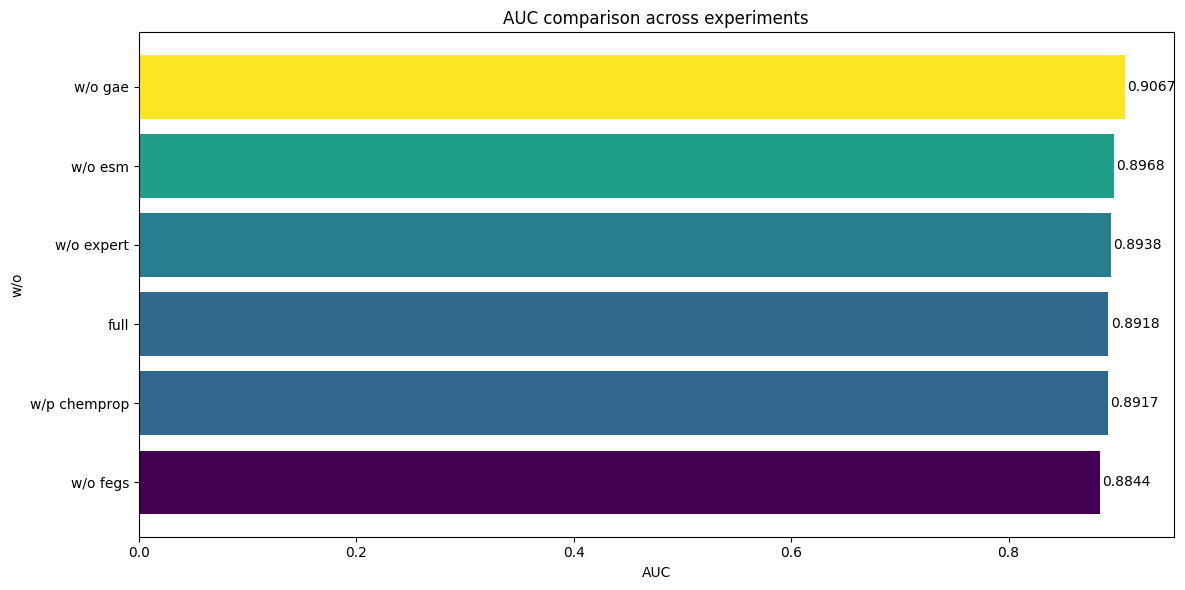

In [68]:
df = exp_df.copy()
df["folds_statistics"] = df["folds_statistics"].apply(parse_if_string)
df = df[df["folds_statistics"].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 5)].copy()

metric_names = ["AUC", "AUPR", "Precision", "Sensitivity", "Specificity"]
for i, metric in enumerate(metric_names):
    df[metric] = df["folds_statistics"].apply(lambda x: x[i])

df["exp_clean"] = df["exp"].astype(str).str.replace("dataset_", "", regex=False)

# sort by AUC and keep top 10
df = df.sort_values("AUC", ascending=False).head(10).copy()

# colors according to AUC
norm = mcolors.Normalize(vmin=df["AUC"].min(), vmax=df["AUC"].max())
colors = cm.viridis(norm(df["AUC"]))

plt.figure(figsize=(12, 6))
bars = plt.barh(df["w/o"], df["AUC"], color=colors)

plt.title("AUC comparison across experiments")
plt.xlabel("AUC")
plt.ylabel("w/o")

for bar, value in zip(bars, df["AUC"]):
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center"
    )

plt.gca().invert_yaxis()  # highest AUC on top
plt.tight_layout()
plt.show()

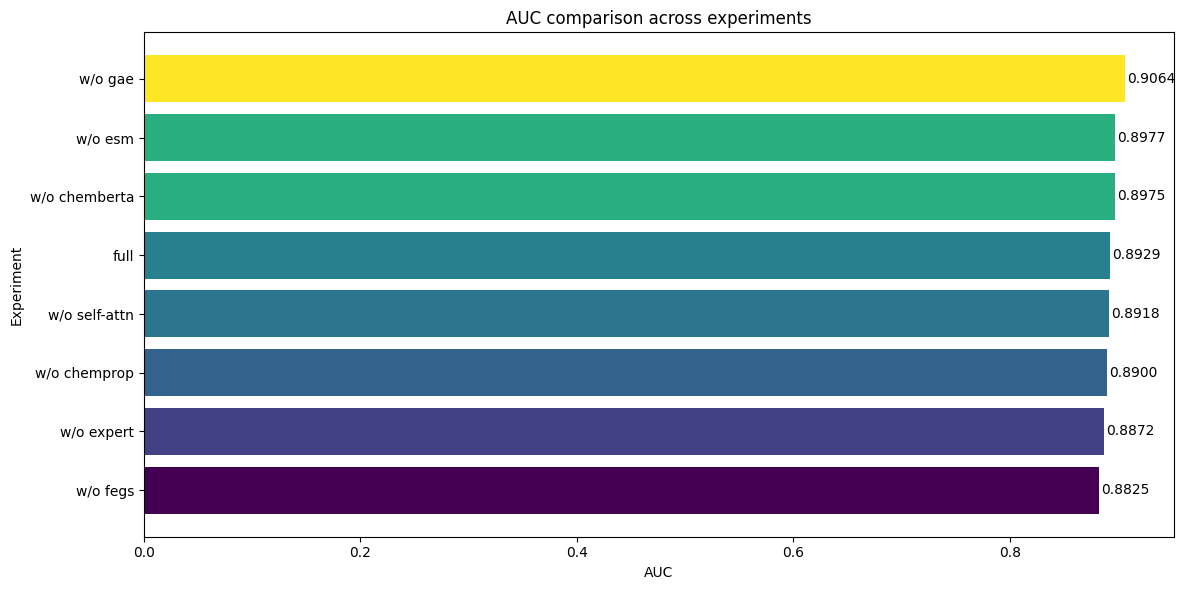

In [41]:
df = exp_df.copy()
df["folds_statistics"] = df["folds_statistics"].apply(parse_if_string)
df = df[df["folds_statistics"].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 5)].copy()

metric_names = ["AUC", "AUPR", "Precision", "Sensitivity", "Specificity"]
for i, metric in enumerate(metric_names):
    df[metric] = df["folds_statistics"].apply(lambda x: x[i])

# keep original experiment names
df["exp_clean"] = df["exp"].astype(str).str.replace("dataset_", "", regex=False)

# sort by best AUC and keep top 5
df = df.sort_values("AUC", ascending=True).reset_index(drop=True)
df = df.tail(10).copy()

# create colors according to AUC values
norm = mcolors.Normalize(vmin=df["AUC"].min(), vmax=df["AUC"].max())
colors = cm.viridis(norm(df["AUC"]))

# plotting pipeline ..
plt.figure(figsize=(12,6))
bars = plt.barh(df["w/o"], df["AUC"], color=colors)

plt.title("AUC comparison across experiments")
plt.xlabel("AUC")
plt.ylabel("Experiment")

for bar, value in zip(bars, df["AUC"]):
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{value:.4f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:

df = exp_df.copy()
df["folds_statistics"] = df["folds_statistics"].apply(parse_if_string)
df = df[df["folds_statistics"].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 5)].copy()
metric_names = ["AUC", "AUPR", "Precision", "Sensitivity", "Specificity"]

for i, metric in enumerate(metric_names):
    df[metric] = df["folds_statistics"].apply(lambda x: x[i])


df["exp_clean"] = df["exp"].str.replace("dataset_", "", regex=False) # remove "dataset_" from experiment names
df = df.sort_values("AUC", ascending=True).reset_index(drop=True) # sort by AUC
df = df.head(5) # best 5

# create colors according to AUC values
norm = mcolors.Normalize(vmin=df["AUC"].min(), vmax=df["AUC"].max())
colors = cm.viridis(norm(df["AUC"]))

# plotting pipeline ..
plt.figure(figsize=(12,6))
bars = plt.barh(df["exp_clean"], df["AUC"], color=colors)

plt.title("AUC comparison across experiments")
plt.xlabel("AUC")
plt.ylabel("Experiment")

for bar, value in zip(bars, df["AUC"]):
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{value:.4f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [20]:
exp_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5,fold1_avg,fold2_avg,fold3_avg,fold4_avg,fold5_avg,folds_statistics,AUC_statistics
0,1,"{""fold1"": [[0.9909742609499845, 0.962579430691...","[[0.8747855917667238, 0.7187101963730369, 0.34...","[[0.8951435661113081, 0.8479080045564223, 0.86...","[[0.913615040546929, 0.8476563970116463, 0.828...","[[0.9435180986764995, 0.8930614383306533, 0.90...","[[0.8669320279535866, 0.8368566719212929, 0.83...","[0.86884, 0.71149, 0.16705, 0.02593, 0.89151]","[0.88442, 0.83349, 0.74888, 0.128, 0.94977]","[0.92422, 0.883, 0.91934, 0.31495, 0.97899]","[0.93927, 0.8875, 0.89951, 0.71577, 0.94123]","[0.87159, 0.85038, 0.85271, 0.46003, 0.91463]","[0.89767, 0.83317, 0.7175, 0.32894, 0.93523]","[0.89767, 0.00082, 0.02871]"
1,2,"{""fold1"": [[0.9913765176199847, 0.959332746444...","[[0.8746797111576986, 0.718766760647358, 0.389...","[[0.8889471818504078, 0.8372364477876479, 0.78...","[[0.9452161896796247, 0.9194659727851098, 0.93...","[[0.94012764464825, 0.8850012855983935, 0.9118...","[[0.8758158623417722, 0.8512358062777288, 0.86...","[0.86386, 0.70757, 0.19326, 0.03165, 0.88899]","[0.87891, 0.82709, 0.71982, 0.12031, 0.93871]","[0.93555, 0.90029, 0.93356, 0.39486, 0.97665]","[0.93683, 0.8845, 0.89541, 0.71332, 0.93899]","[0.85971, 0.83414, 0.83466, 0.32969, 0.9301]","[0.89497, 0.83072, 0.71534, 0.31797, 0.93469]","[0.89497, 0.00117, 0.03426]"
2,3,"{""fold1"": [[0.9914178522652731, 0.961212472872...","[[0.8710691823899371, 0.7123161952213743, 0.40...","[[0.8772208436724566, 0.8065882378734059, 0.47...","[[0.9466889705080186, 0.904030411272933, 0.913...","[[0.9267805658456457, 0.8794039926312637, 0.85...","[[0.8596167369901547, 0.8283654959673532, 0.83...","[0.85636, 0.70068, 0.16326, 0.02593, 0.88994]","[0.87967, 0.82096, 0.66455, 0.08615, 0.94101]","[0.92384, 0.87347, 0.89562, 0.29907, 0.97121]","[0.92295, 0.87258, 0.87775, 0.70168, 0.9286]","[0.86719, 0.8411, 0.84981, 0.36068, 0.92968]","[0.89, 0.82176, 0.6902, 0.2947, 0.93209]","[0.89, 0.0008, 0.02825]"
3,4,"{""fold1"": [[0.9916053704121903, 0.964060218950...","[[0.8776867204540161, 0.7244434089072103, 0.52...","[[0.8547607231478199, 0.7959052377987086, 0.45...","[[0.9573075384559439, 0.9305132957613872, 0.94...","[[0.9343348704304157, 0.8802970320623299, 0.89...","[[0.8584373534927332, 0.8388068805006051, 0.85...","[0.86413, 0.7081, 0.2973, 0.05825, 0.88962]","[0.86913, 0.82663, 0.73713, 0.12554, 0.947]","[0.93389, 0.89386, 0.91834, 0.34907, 0.97626]","[0.93815, 0.88654, 0.90101, 0.7242, 0.9419]","[0.85911, 0.83307, 0.83836, 0.32109, 0.9346]","[0.89288, 0.82964, 0.73843, 0.31563, 0.93788]","[0.89288, 0.00125, 0.03539]"
4,5,"{""fold1"": [[0.9881588003140088, 0.942750589238...","[[0.8652775130762552, 0.7074404314583583, 0.19...","[[0.9108117688762849, 0.8643998977713873, 0.84...","[[0.9523619040692389, 0.935636326695546, 0.963...","[[0.9397366687484495, 0.890785229703163, 0.917...","[[0.8663524085794656, 0.8508944259960864, 0.86...","[0.86173, 0.70318, 0.14448, 0.02054, 0.89057]","[0.87992, 0.83088, 0.71572, 0.11385, 0.94793]","[0.94647, 0.91774, 0.93553, 0.42523, 0.97665]","[0.93701, 0.88652, 0.89811, 0.71975, 0.94034]","[0.86264, 0.84058, 0.84884, 0.3556, 0.93207]","[0.89755, 0.83578, 0.70854, 0.32699, 0.93751]","[0.89755, 0.00135, 0.03678]"
5,6,"{""fold1"": [[0.9870709934294717, 0.949939647498...","[[0.8418143701162568, 0.6795748253297168, 0.02...","[[0.8823254165189649, 0.8527843020623672, 0.88...","[[0.8746863522309902, 0.8317617757660953, 0.92...","[[0.9259370160924655, 0.8708447179613843, 0.87...","[[0.8723161700070323, 0.848409901965693, 0.848...","[0.83859, 0.67861, 0.05382, 0.00707, 0.88585]","[0.88424, 0.84077, 0.73508, 0.12, 0.95438]","[0.88897, 0.82935, 0.87739, 0.20421, 0.9786]","[0.92549, 0.87141, 0.88503, 0.67443, 0.93575]","[0.8754, 0.85279, 0.86468, 0.30378, 0.94824]","[0.88254, 0.81459, 0.6832, 0.2619, 0.94056]","[0.88254, 0.00077, 0.02783]"
6,7,"{""fold1"": [[0.9878983584432902, 0.948502849081...","[[0.864546936873981, 0.70657324118

In [34]:
arr = np.array(ast.literal_eval(exp_df.iloc[0, 2]), dtype=float)
arr

array([[0.88070886, 0.85510655, 0.94779116, 0.05446573, 0.99699977],
       [0.8239213 , 0.79013798, 0.88770865, 0.13501039, 0.98292176],
       [0.85333471, 0.82976187, 0.90045662, 0.22755597, 0.97484422],
       [0.85212443, 0.84182692, 0.91139241, 0.31571659, 0.96930533],
       [0.832838  , 0.79349952, 0.88068182, 0.14308793, 0.98061389],
       [0.80241233, 0.76031212, 0.81988473, 0.13131779, 0.97115163],
       [0.77814913, 0.70351534, 0.71629213, 0.11770136, 0.95338103],
       [0.71087336, 0.69571224, 0.8277439 , 0.12531733, 0.97392107],
       [0.84465077, 0.81754525, 0.87161773, 0.34941149, 0.9485345 ],
       [0.80865858, 0.75728942, 0.85242718, 0.10131549, 0.98246019]])

In [37]:
var0 = arr[:, 0].var()
print(var0)

0.0020699471142112858


In [43]:
exp_df.to_csv(PREPROCESSED_ABLATION_STRUDY_PATH, index=False)

In [48]:
exp_df.tail()

,job_id,exp_in_job,hyperparameters,val_res,fold1,fold2,fold3,fold4,fold5,exp,fold1_avg,fold2_avg,fold3_avg,fold4_avg,fold5_avg,folds_statistics,AUC_statistics
136,2503@j11,12,"{""lr"": 5e-05, ""weight_decay"": 1e-05, ""mlp_drop...","{""fold1"": [[0.9885708918675952, 0.954392582900...","[[0.7610592296126887, 0.6252066559064285, 0.0,...","[[0.7670187876639489, 0.7298119580761224, 0.0,...","[[0.9090876031855704, 0.8323568665852585, 0.84...","[[0.886002720576283, 0.8341739366379153, 0.882...","[[0.879450158227848, 0.865763308084672, 0.8857...",137,"[0.76106, 0.62521, 0.0, 0.0, 0.98428]","[0.76702, 0.72981, 0.0, 0.0, 0.96313]","[0.90909, 0.83236, 0.84314, 0.20093, 0.96887]","[0.886, 0.83417, 0.88293, 0.55436, 0.94637]","[0.87945, 0.86576, 0.88579, 0.41406, 0.94233]","[0.84052, 0.77746, 0.52237, 0.23387, 0.961]","[0.84052, 0.004, 0.06325]"
137,2503@j7,12,"{""lr"": 5e-05, ""weight_decay"": 1e-05, ""mlp_drop...","{""fold1"": [[0.9900843966778033, 0.956863715585...","[[0.901806323189971, 0.881599365860845, 1.0, 0...","[[0.7646508330379299, 0.7493856425931937, 0.40...","[[0.8973053565584204, 0.8423395159186423, 0.92...","[[0.9357191133316792, 0.8841154287379088, 0.92...","[[0.8640907026488513, 0.8515536496691242, 0.89...",138,"[0.90181, 0.8816, 1.0, 0.06397, 1.0]","[0.76465, 0.74939, 0.40909, 0.02769, 0.94009]","[0.89731, 0.84234, 0.92857, 0.24299, 0.98444]","[0.93572, 0.88412, 0.92478, 0.64012, 0.96201]","[0.86409, 0.85155, 0.89369, 0.35026, 0.95499]","[0.87272, 0.8418, 0.83123, 0.26501, 0.96831]","[0.87272, 0.00343, 0.05861]"
138,2503@j8,10,"{""lr"": 5e-05, ""weight_decay"": 0.0001, ""mlp_dro...","{""fold1"": [[0.9899502207194516, 0.958506719780...","[[0.8100184232259704, 0.784398765060522, 0.5, ...","[[0.6088479262672811, 0.6310904441457004, 0.14...","[[0.9328157387541365, 0.8808654560865383, 0.92...","[[0.9135951816711867, 0.8440113388353183, 0.86...","[[0.8011438554852321, 0.7866471489804578, 0.84...",139,"[0.81002, 0.7844, 0.5, 0.00337, 0.99686]","[0.60885, 0.63109, 0.14286, 0.00615, 0.9447]","[0.93282, 0.88087, 0.92308, 0.39252, 0.97276]","[0.9136, 0.84401, 0.86, 0.59265, 0.92961]","[0.80114, 0.78665, 0.84158, 0.22135, 0.95499]","[0.81329, 0.7854, 0.6535, 0.24321, 0.95978]","[0.81329, 0.01326, 0.11516]"
139,2503@j8,11,"{""lr"": 5e-05, ""weight_decay"": 1e-05, ""mlp_drop...","{""fold1"": [[0.9870117672315475, 0.941932816618...","[[0.9316964191178028, 0.8818646533940083, 0.0,...","[[0.8505919886565049, 0.8140710834685241, 0.70...","[[0.8890141459689442, 0.8496807129309878, 0.96...","[[0.9229666258865401, 0.8683931994186124, 0.86...","[[0.7976075363338022, 0.7749464330586204, 0.77...",140,"[0.9317, 0.88186, 0.0, 0.0, 0.99057]","[0.85059, 0.81407, 0.70833, 0.05231, 0.96774]","[0.88901, 0.84968, 0.96471, 0.38318, 0.98833]","[0.92297, 0.86839, 0.8643, 0.634, 0.92737]","[0.79761, 0.77495, 0.77591, 0.36068, 0.88748]","[0.87838, 0.83779, 0.66265, 0.28603, 0.9523]","[0.87838, 0.00245, 0.04948]"
140,2503@j8,12,"{""lr"": 5e-05, ""weight_decay"": 1e-05, ""mlp_drop...","{""fold1"": [[0.9899502207194516, 0.958506719780...","[[0.8100184232259704, 0.784398765060522, 0.5, ...","[[0.6088479262672811, 0.6310904441457004, 0.14...","[[0.9328157387541365, 0.8808654560865383, 0.92...","[[0.9135951816711867, 0.8440113388353183, 0.86...","[[0.8011438554852321, 0.7866471489804578, 0.84...",141,"[0.81002, 0.7844, 0.5, 0.00337, 0.99686]","[0.60885, 0.63109, 0.14286, 0.00615, 0.9447]","[0.93282, 0.88087, 0.92308, 0.39252, 0.97276]","[0.9136, 0.84401, 0.86, 0.59265, 0.92961]","[0.80114, 0.78665, 0.84158, 0.22135, 0.95499]","[0.81329, 0.7854, 0.6535, 0.24321, 0.95978]","[0.81329, 0.01326, 0.11516]"


## Analyse first and last 5 Experiment Results ##

In [22]:
EXP_1503_VPATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_eval_neg_smoo_1503.csv' # VICTOR

In [39]:
exp_df = pd.read_csv(EXP_1503_VPATH)
exp_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5
0,dataset_neg_fct_5_smoo_fct_0.9_1503@j2,"{""fold1"": [[0.9870957605022931, 0.947628508007...","[[0.6824265053651657, 0.6653360699265691, 0.86...","[[0.8487502252293029, 0.7935045520580875, 0.85...","[[0.9073943741272916, 0.8927620617085753, 0.94...","[[0.9668525379959322, 0.9519494170034655, 0.96...","[[0.9306467986568248, 0.9283141228187478, 0.96..."
1,dataset_neg_fct_5_smoo_fct_0.9_1503@j4,"{""fold1"": [[0.9882161502896648, 0.952728321791...","[[0.6783838183484806, 0.6620224861231838, 0.86...","[[0.8446870455001988, 0.7952797381935002, 0.86...","[[0.8950638484752939, 0.8768462983775632, 0.89...","[[0.9633692614192145, 0.9483151762604894, 0.95...","[[0.9235744334578224, 0.9238609428227462, 0.97..."
2,dataset_neg_fct_5_smoo_fct_0.9_1503@j5,"{""fold1"": [[0.9883505597281943, 0.952452278910...","[[0.730374727884913, 0.6926091143460115, 0.836...","[[0.8360985887929346, 0.7845121412963442, 0.85...","[[0.899679350029278, 0.8805304907317271, 0.890...","[[0.9647130156439735, 0.9497697359149242, 0.95...","[[0.9320016777132869, 0.9309840308815354, 0.96..."
3,dataset_neg_fct_5_smoo_fct_0.9_1503@j3,"{""fold1"": [[0.9887220524819077, 0.954915661273...","[[0.6868571929003444, 0.6953161318295789, 0.87...","[[0.8271329538273463, 0.7738090033175761, 0.83...","[[0.9049831651727399, 0.8872107798438864, 0.90...","[[0.9679387554093437, 0.9530693111775712, 0.95...","[[0.932203053538644, 0.930425346271282, 0.9659..."
4,dataset_neg_fct_5_smoo_fct_0.9_1503@j1,"{""fold1"": [[0.9880948084354368, 0.952343636811...","[[0.7238813739162155, 0.6913263422011363, 0.88...","[[0.8354459626408168, 0.7810172662725587, 0.87...","[[0.9019906197919012, 0.8844658963023292, 0.93...","[[0.9616815255696092, 0.9466335961397551, 0.95...","[[0.9264212215661504, 0.9252393370070784, 0.97..."
5,dataset_neg_fct_5_smoo_fct_0.9_1503@j6,"{""fold1"": [[0.9886094223505473, 0.955574571490...","[[0.7014828985436641, 0.6996680809228946, 0.88...","[[0.8593038884276537, 0.8040586509357075, 0.84...","[[0.8997659170758073, 0.8823510260755983, 0.90...","[[0.9659196477746596, 0.9514438772700716, 0.95...","[[0.9343914647592306, 0.9331078131621698, 0.96..."
6,dataset_neg_fct_5_smoo_fct_0.9_1503@j5_a,"{""fold1"": [[0.9878894606821279, 0.946923958226...","[[0.6988910086824541, 0.6398976402936377, 0.63...","[[0.81553569227082, 0.7614315531248477, 0.8184...","[[0.8904708684293502, 0.874967475270621, 0.934...","[[0.9665354943726014, 0.953223514298627, 0.963...","[[0.9333318933798137, 0.9300774467438241, 0.96..."
7,dataset_neg_fct_5_smoo_fct_0.9_1503@j1_a,"{""fold1"": [[0.9907854862697025, 0.961705364346...","[[0.7625489024196095, 0.7246311502236481, 0.89...","[[0.8254039686911873, 0.7684598090538375, 0.84...","[[0.9044074591234629, 0.8889397844141352, 0.92...","[[0.9692383884127787, 0.9546969739458493, 0.96...","[[0.9339888638013265, 0.930285980776724, 0.960..."
8,dataset_neg_fct_5_smoo_fct_0.9_1503@j3_a,"{""fold1"": [[0.9894392139536908, 0.953832569975...","[[0.7608237790380546, 0.7120432799219278, 0.73...","[[0.7988394117226141, 0.7401067254238999, 0.78...","[[0.9057182812711141, 0.8908439616187876, 0.93...","[[0.9729379885090259, 0.9585552279757699, 0.96...","[[0.9305289066483154, 0.9279480826557372, 0.96..."
9,dataset_neg_fct_5_smoo_fct_0.9_1503@j6_a,"{""fold1"": [[0.9876940691835249, 0.947326664320...","[[0.7089894616391311, 0.6547025714321113, 0.72...","[[0.823244353749238, 0.7719416572787667, 0.853...","[[0.8985532746272691, 0.882526640290105, 0.924...","[[0.9689103475287701, 0.9551114968200917, 0.96...","[[0.9179600211974552, 0.9187749406862491, 0.96..."


In [34]:
best_exp_df = exp_df[exp_df['exp'] == 'dataset_neg_fct_5_smoo_fct_0.9_1503@j6'].iloc[:,2:]
best_exp_df

,fold1,fold2,fold3,fold4,fold5
5,"[[0.7014828985436641, 0.6996680809228946, 0.88...","[[0.8593038884276537, 0.8040586509357075, 0.84...","[[0.8997659170758073, 0.8823510260755983, 0.90...","[[0.9659196477746596, 0.9514438772700716, 0.95...","[[0.9343914647592306, 0.9331078131621698, 0.96..."


In [43]:
best_exp_df.iloc[0, 0]

'[[0.7014828985436641, 0.6996680809228946, 0.8811881188118812, 0.14378029079159935, 0.9806138933764136], [0.743015193207149, 0.6751909444521739, 0.6906666666666667, 0.13947226709746904, 0.9375336564351104], [0.7457529457445942, 0.6793712289735393, 0.6984536082474226, 0.14593430263866453, 0.9369951534733441], [0.742062591037304, 0.7119505689946534, 0.8986784140969163, 0.1098546042003231, 0.9876144318793754], [0.721046766241867, 0.6892103004530203, 0.8297213622291022, 0.14431879375336565, 0.970382337102854], [0.7541074262661273, 0.7132626925287218, 0.8669201520912547, 0.12277867528271405, 0.9811523963381799], [0.7523973821274433, 0.7191472966940299, 0.8284182305630027, 0.16639741518578352, 0.9655358104469575], [0.747457770145361, 0.7250876637007182, 0.8858858858858859, 0.15885837372105546, 0.979536887452881], [0.7562170703408981, 0.7142922694640544, 0.8916666666666667, 0.11523963381798599, 0.9859989229940764], [0.7488363609263178, 0.6919993542106965, 0.8267326732673267, 0.089929994614970

In [45]:
lst = ast.literal_eval(best_exp_df.iloc[0, 0])

In [46]:
import pandas as pd
import numpy as np
import ast

# example: keep only one experiment, only fold columns
best_exp_df = exp_df[exp_df['exp'] == 'dataset_neg_fct_5_smoo_fct_0.9_1503@j6'].iloc[:, 2:].copy()

fold_cols = best_exp_df.columns.tolist()

# parse each fold cell from string -> python list
for fold in fold_cols:
    best_exp_df[fold] = best_exp_df[fold].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# take the single row
row = best_exp_df.iloc[0]

def avg_first_last_5(exp_list):
    arr = np.array(exp_list, dtype=float)   # expected shape: (10, 5)

    if arr.shape != (10, 5):
        raise ValueError(f"Expected shape (10, 5), got {arr.shape}")

    first5 = arr[:5].mean(axis=0)
    last5 = arr[5:].mean(axis=0)

    return {
        "AUC_first5": first5[0],
        "AUPR_first5": first5[1],
        "Precision_first5": first5[2],
        "Sensitivity_first5": first5[3],
        "Specificity_first5": first5[4],

        "AUC_last5": last5[0],
        "AUPR_last5": last5[1],
        "Precision_last5": last5[2],
        "Sensitivity_last5": last5[3],
        "Specificity_last5": last5[4],
    }

# per-fold summary
per_fold_results = {}

for fold in fold_cols:
    per_fold_results[fold] = avg_first_last_5(row[fold])

per_fold_df = pd.DataFrame(per_fold_results).T
per_fold_df.index.name = "fold"
per_fold_df = per_fold_df.reset_index()

# add differences: last5 - first5
metrics = ["AUC", "AUPR", "Precision", "Sensitivity", "Specificity"]
for metric in metrics:
    per_fold_df[f"{metric}_diff"] = per_fold_df[f"{metric}_last5"] - per_fold_df[f"{metric}_first5"]

display(per_fold_df)

,fold,AUC_first5,AUPR_first5,Precision_first5,Sensitivity_first5,Specificity_first5,AUC_last5,AUPR_last5,Precision_last5,Sensitivity_last5,Specificity_last5,AUC_diff,AUPR_diff,Precision_diff,Sensitivity_diff,Specificity_diff
0,fold1,0.730672,0.691078,0.799742,0.136672,0.962628,0.751803,0.712758,0.859925,0.130641,0.978675,0.021131,0.021680,0.060183,-0.006031,0.016047
1,fold2,0.828068,0.772900,0.847162,0.210399,0.962117,0.839071,0.779661,0.832028,0.204643,0.958960,0.011003,0.006761,-0.015135,-0.005757,-0.003157
2,fold3,0.897293,0.880890,0.922548,0.340772,0.971309,0.895084,0.881230,0.924892,0.347651,0.971812,-0.002208,0.000340,0.002344,0.006879,0.000503
3,fold4,0.968269,0.953529,0.959038,0.600690,0.974339,0.962743,0.948713,0.962637,0.600184,0.976730,-0.005525,-0.004816,0.003599,-0.000506,0.002391
4,fold5,0.934047,0.930669,0.965505,0.505547,0.981870,0.927043,0.926484,0.964528,0.509287,0.981173,-0.007004,-0.004185,-0.000977,0.003740,-0.000697


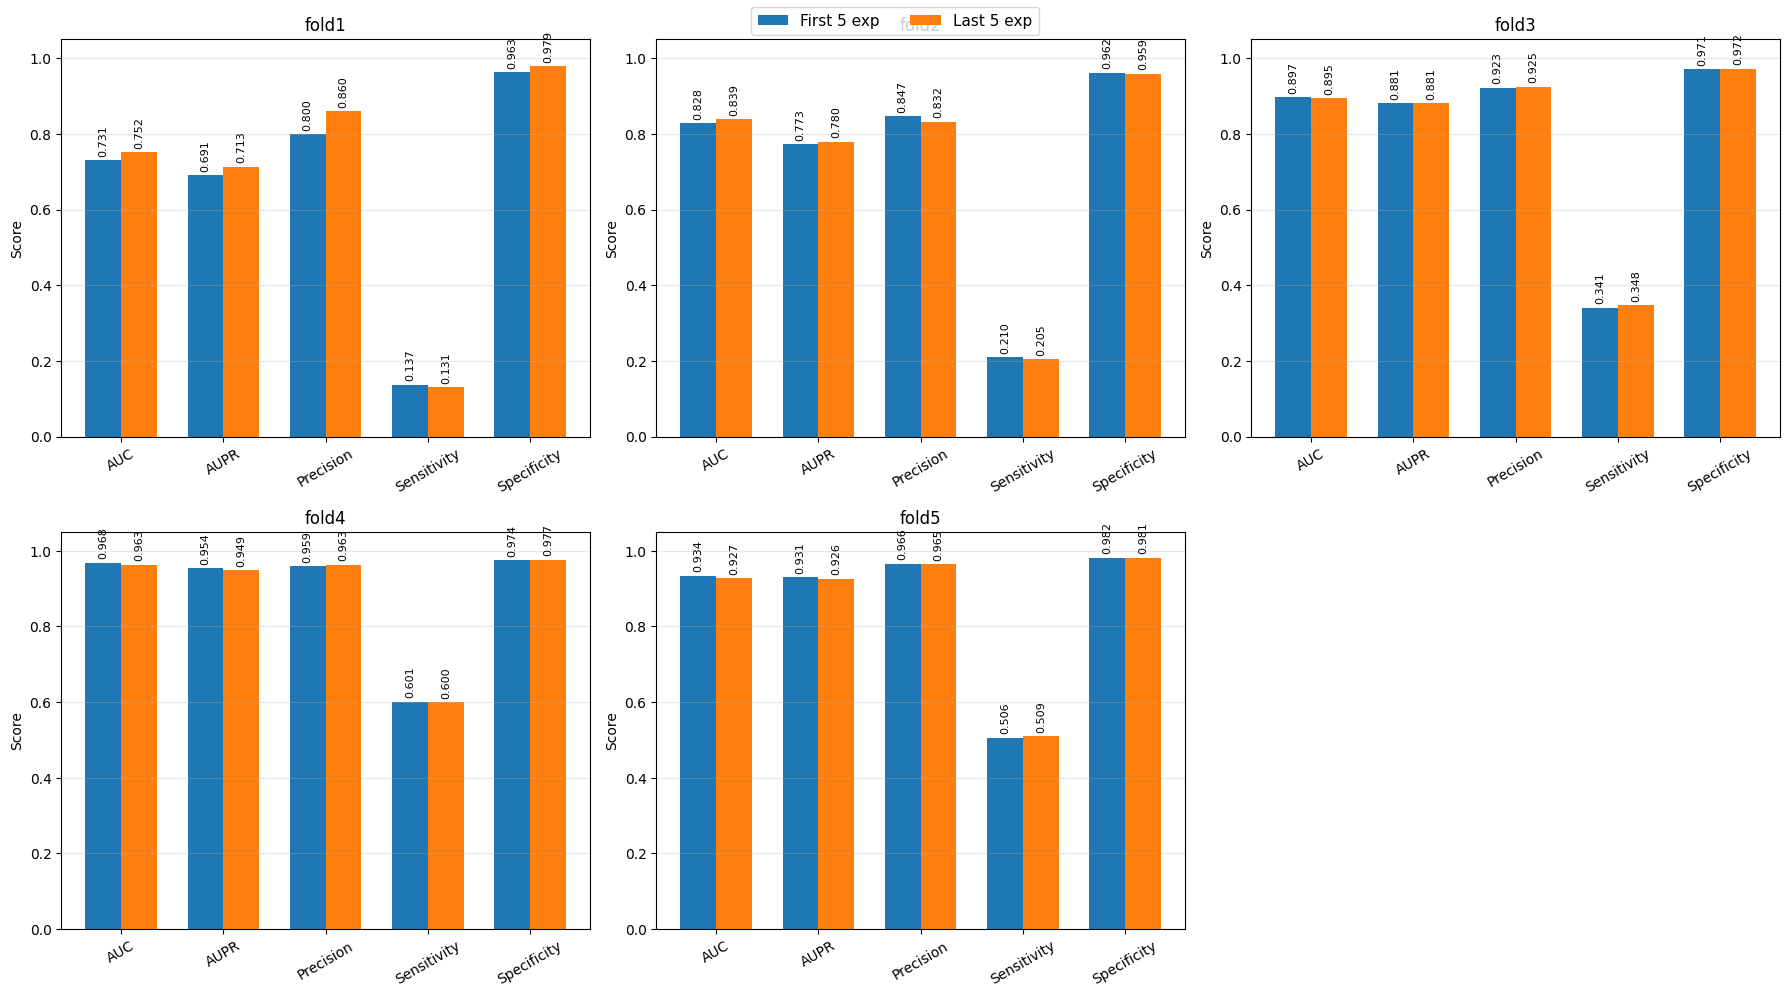

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# per_fold_df is expected to contain columns like:
# fold, AUC_first5, AUC_last5, AUPR_first5, AUPR_last5, ...

metrics = ["AUC", "AUPR", "Precision", "Sensitivity", "Specificity"]

n_folds = len(per_fold_df)
ncols = 3
nrows = int(np.ceil(n_folds / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 10))
axes = np.array(axes).reshape(-1)

x = np.arange(len(metrics))
bar_width = 0.35

for i, (_, row) in enumerate(per_fold_df.iterrows()):
    ax = axes[i]

    first_vals = [row[f"{m}_first5"] for m in metrics]
    last_vals  = [row[f"{m}_last5"] for m in metrics]

    ax.bar(x - bar_width/2, first_vals, width=bar_width, label="First 5 exp")
    ax.bar(x + bar_width/2, last_vals,  width=bar_width, label="Last 5 exp")

    ax.set_title(f"{row['fold']}")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=30)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

    # add values above bars
    for xi, v in zip(x - bar_width/2, first_vals):
        ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8, rotation=90)

    for xi, v in zip(x + bar_width/2, last_vals):
        ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8, rotation=90)

# hide unused subplots if fewer than grid slots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=11)

fig.suptitle("First 5 vs Last 5 Experiments per Fold", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [54]:
import numpy as np
import ast

fold_cols = best_exp_df.columns.tolist()

# make sure parsed
for fold in fold_cols:
    best_exp_df[fold] = best_exp_df[fold].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

row = best_exp_df.iloc[0]

first5_fold_avgs = []
last5_fold_avgs = []

for fold in fold_cols:
    arr = np.array(row[fold], dtype=float)

    first5_avg = np.round(arr[:5].mean(axis=0), 5)
    last5_avg  = np.round(arr[5:10].mean(axis=0), 5)

    first5_fold_avgs.append(first5_avg)
    last5_fold_avgs.append(last5_avg)

# average across folds
first5_all_folds_avg = np.round(np.mean(first5_fold_avgs, axis=0), 5)
last5_all_folds_avg  = np.round(np.mean(last5_fold_avgs, axis=0), 5)

print("First 5 (AUC, AUPR, Precision, Sensitivity, Specificity):", first5_all_folds_avg.tolist())
print("Last 5 (AUC, AUPR, Precision, Sensitivity, Specificity):", last5_all_folds_avg.tolist())

First 5 (AUC, AUPR, Precision, Sensitivity, Specificity): [0.87167, 0.84581, 0.8988, 0.35882, 0.97045]
Last 5 (AUC, AUPR, Precision, Sensitivity, Specificity): [0.87515, 0.84977, 0.9088, 0.35848, 0.97347]
